# Compare against a CompressAI Baseline


CompressAI is a library that collects pretrained weights of leading neural codecs; targeting maximum compressability of their latent spaces.

We do not expect to compete with them in terms of compression.  HBQ's latent space is designed to have a smoothly varying latent space optimzed for generation.

Algoritms we'll compare:

* Balle 2018 factorized prior
* Minnen 2018 mean-scale hyperprior
* Cheng 2020 attention

Note that CompressAI models use [0,1] for images, unlike GRN's [-1,1]

In [1]:
import math
import time
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
import hierarchical_binary_quantization.misc.image_helpers as ih
import hierarchical_binary_quantization.misc.dataset_helpers as dh
import IPython.display as ipd
from compressai.zoo import bmshj2018_factorized, mbt2018_mean, cheng2020_anchor
import lpips
from pytorch_msssim import ssim as ssim_fn


device = 'cpu'
target_size = 256
W,H = 256,256


/home/ron/proj/hierarchical-binary-quantization/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
lpips_fn = lpips.LPIPS(net="alex").eval().requires_grad_(False).cpu()

def compute_lpips(a,b):
    # [B, 3, H, W], [-1,1]
    with torch.no_grad():
        return lpips_fn(a*2-1,b*2-1).mean().item()
def compute_ssim(a,b):
    # [B, 3, H, W], [0,1]
    with torch.no_grad():
        return ssim_fn(a,b,data_range=1.0).item()

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/home/ron/proj/hierarchical-binary-quantization/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:207: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/ron/proj/hierarchical-binary-quantization/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:222: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /home/ron/proj/hierarchical-binary-quantization/.venv/lib/python3.12/site-packages/lpips/weights/v0.1/alex.pth


In [3]:
transform = transforms.Compose([dh.PadToRectangle(width=W, height=H), transforms.ToTensor()])
img_ds = dh.ImageDataset(dh.BlobDataset("data/dbs/fantasy_256x256.sqlite3"), transform=transform)
img_dl = DataLoader(img_ds, batch_size=2)
batch = next(iter(img_dl))
imgs = batch[1]
imgs.shape, imgs.min(), imgs.max()

(torch.Size([2, 3, 256, 256]), tensor(0.), tensor(1.))

In [4]:
def load_compressai_model(fn,quality):
    name = fn.__name__
    model = fn(quality=quality,pretrained=True).eval().cpu()
    model.update(force=True)
    model.eval()
    lbl = f"{name}(quality={quality})"
    n_params = sum(p.numel() for p in model.parameters()) / 1_000_000
    print(lbl,n_params, "params")
    return lbl, model

families = [bmshj2018_factorized, mbt2018_mean, cheng2020_anchor]
models = dict([load_compressai_model(f,quality) for f in families for quality in [1,6]])



bmshj2018_factorized(quality=1) 2.998147 params
bmshj2018_factorized(quality=6) 7.030531 params
mbt2018_mean(quality=1) 7.028003 params
mbt2018_mean(quality=6) 17.561699 params
cheng2020_anchor(quality=1) 11.833149 params
cheng2020_anchor(quality=6) 26.598956 params


bmshj2018_factorized(quality=1)    :  mse: 0.00; psnr: 24.93; lpips: 0.16; ssim: 0.83; bpp_actual: 0.15; 



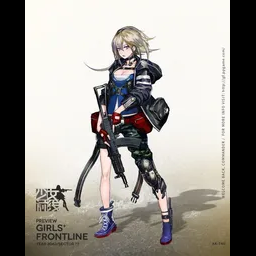
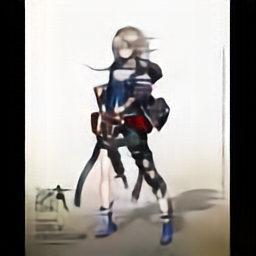

bmshj2018_factorized(quality=6)    :  mse: 0.00; psnr: 34.13; lpips: 0.01; ssim: 0.97; bpp_actual: 0.95; 



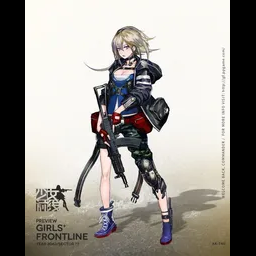
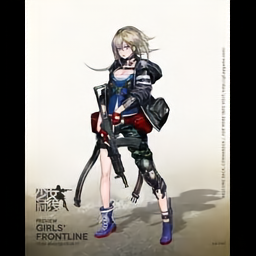

mbt2018_mean(quality=1)            :  mse: 0.00; psnr: 26.19; lpips: 0.12; ssim: 0.86; bpp_actual: 0.16; 



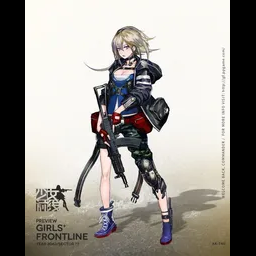
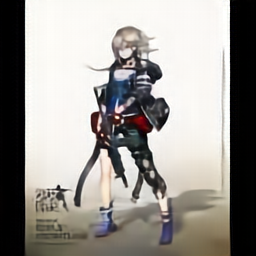

mbt2018_mean(quality=6)            :  mse: 0.00; psnr: 37.27; lpips: 0.01; ssim: 0.98; bpp_actual: 0.85; 



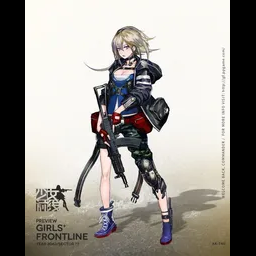
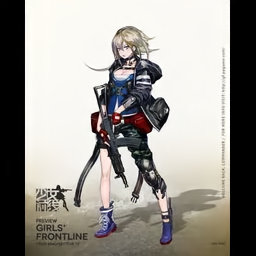

cheng2020_anchor(quality=1)        :  mse: 0.00; psnr: 28.05; lpips: 0.08; ssim: 0.92; bpp_actual: 0.16; 



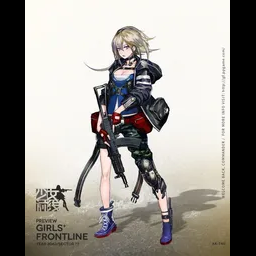
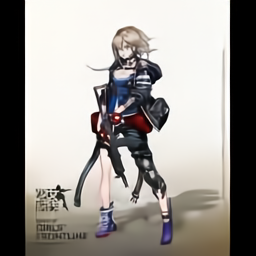

cheng2020_anchor(quality=6)        :  mse: 0.00; psnr: 36.19; lpips: 0.01; ssim: 0.98; bpp_actual: 0.70; 



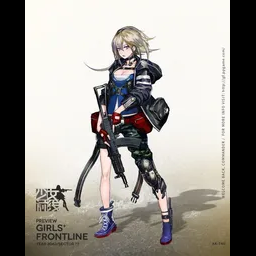
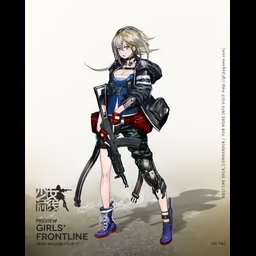

In [5]:
def round_trip_image_through_compressai_model(imgs,m):
    B,C,H,W = imgs.shape
    with torch.no_grad():
        y = m.g_a(imgs) # prequant latent from compressai
        y_hat_approx = torch.round(y) # what bmshj2018 uses;  mbt2018 and cheng2020 use something more complicated
        compressai_output = m(imgs)
        x_hat_forward = compressai_output["x_hat"].clamp(0,1)
        bpp_forward = sum(
            (-torch.log2(l).sum() / (B * H * W)).item()
            for l in compressai_output["likelihoods"].values()
        )
        enc = m.compress(imgs)
        n_bytes = sum(len(s[0]) for s in enc["strings"])
        bpp_actual = n_bytes * 8 / (H*W)
        dec = m.decompress(enc["strings"],enc["shape"])
        x_hat_actual = dec["x_hat"].clamp(0,1)

    mse = F.mse_loss(x_hat_actual, imgs).item()
    psnr = 10 * math.log10(1.0/max(mse,1e-12))
    lpips_score = compute_lpips(x_hat_actual, imgs)
    ssim_score = compute_ssim(x_hat_actual, imgs)

    return {
        "x_hat_f": x_hat_forward,
        "x_hat_actual": x_hat_actual,
        "latent": y,
        "latent_quantized_approx": y_hat_approx,
        "bpp_forward": bpp_forward,
        "bpp_actual": bpp_actual,
        "mse": mse,
        "psnr": psnr,
        "lpips": lpips_score,
        "ssim": ssim_score,
    }
    
for name, model in models.items():
    print(f"{name:35s}: ", end=" ")
    result = round_trip_image_through_compressai_model(imgs,model)
    for score in ["mse","psnr","lpips","ssim", "bpp_actual"]:
        print(f"{score}: {result[score]:.2f};", end=" ")
    print("")

    orig = ih.tensor_to_pil(imgs[0]*2-1)
    recon = ih.tensor_to_pil(result['x_hat_actual'][0]*2-1)
    latent_rgb = ih.tensor_to_pil(ih.q_out_to_rgb(result["latent"])[0])

    h = ih.html_for_images([orig,latent_rgb,recon])
    ipd.display(ipd.HTML(h))


## See if a compressAI model can work with a HBQ-like quantizer at the bottleneck.

In [6]:
import hierarchical_binary_quantization.hbq as hbq
import torch.nn as nn

class HBQNeckWrapper(nn.Module):
    def __init__(self, backbone, quant_dim=32, n_rounds=16):
        super().__init__()
        self.g_a = backbone.g_a
        self.g_s = backbone.g_s
        with torch.no_grad():
            shape_probe = self.g_a(torch.zeros(1,3,256,256))
        native_channels = shape_probe.shape[1]
        self.pre_quant = nn.Sequential(
            nn.Conv2d(native_channels, quant_dim, kernel_size=1), nn.Tanh(),
        )
        self.post_quant = nn.Conv2d(quant_dim,native_channels,kernel_size=1)
        self.quantizer = hbq.HBQQuantizer(n_rounds = n_rounds)
        self.quant_dim = quant_dim
        self.n_rounds = n_rounds
    def forward(self,imgs):
        y = self.g_a(imgs)
        z = self.pre_quant(y)
        q_out, q_aux = self.quantizer(z)
        x_hat = self.g_s(self.post_quant(q_out))
        return x_hat, z, q_out, q_aux

backbone = bmshj2018_factorized(quality=6, pretrained=True).eval()
neck_model = HBQNeckWrapper(backbone, quant_dim=16, n_rounds=4).to(device)
with torch.no_grad():
    x_hat, z, q_out, q_aux = neck_model(imgs)
h_lat, w_lat = z.shape[-2:]
bpp = (neck_model.quant_dim * neck_model.n_rounds * h_lat * w_lat) / (imgs.shape[-2] * imgs.shape[-1])
print(f"latent shape {h_lat}x{w_lat} bpp: {bpp:.3f}")


latent shape 16x16 bpp: 0.250


## Train an adapter to a HBQ quantizer

In [8]:
# optimizer = torch.optim.AdamW(neck_model.parameters(), lr=3e-4, weight_decay=1e-4)

# t0 = time.time()
# max_seconds = 999
# step=0
# neck_model.train()
# train_loader = DataLoader(dataset, batch_size=4, shuffle=True)
# while epoch in range(10):
#     for batch in train_loader:
#         batch = batch.to(device)
#         optimizer.zero_grad()
#         x_hat, z, q_out, q_aux = neck_model(batch)
#         loss = F.l1_loss(x_hat, batch)
#         loss.backward()
#         optimizer.step()
#         step += 1
#         if step % 10 == 0:
#             mse = F.mse_loss(x_hat.clamp(0,1),batch).item()
#             psnr = 10 * math.log10(1.0 / max(mse,1e-12))
#             print(f"step {step} t={time.time()-t0:5.1f} loss={loss.item():.4f} psnr={psnr:.2f}dB")
# print("done")

In [ ]:
# Work-in-progress -- still need to do this.....